In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = True
from scipy.integrate import quad
from scipy.optimize import minimize
import time
from numba import njit, prange
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from numba import njit

In [ ]:
# ── at the top of the notebook ──────────────────────────────────────────
from google.colab import drive
import os
import matplotlib # Import matplotlib here to modify its rcParams

drive.mount('/content/drive')
save_dir = "/content/drive/MyDrive/SVM_results"
os.makedirs(save_dir, exist_ok=True)

# Disable LaTeX rendering to avoid the 'latex not found' error
matplotlib.rcParams['text.usetex'] = False


Mounted at /content/drive


In [ ]:
def load_and_convert_dataset(d=2000, p=1000, noise=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((d, p))                  # random Gaussian entries
    x_star = rng.standard_normal(p)                  # ground-truth signal
    b = A @ x_star + noise * rng.standard_normal(d)  # noisy linear targets
    return A, b

In [ ]:
def step_sizes(a, block_vector, length_vector, cases, alpha1, acst, factor=1.9):
    beta2 = (1.0 + acst*acst) / (acst*acst)
    out = np.zeros(cases)
    for i in range(cases):
        block  = int(block_vector[i])
        length = int(length_vector[i])
        step = 0.0
        for l in range(block):
            start, end = l*length, (l+1)*length
            a_block = a[:, start:end]
            step = max(step, np.linalg.norm(a_block, ord=2)**2)
        out[i] = factor / (beta2 * (step + alpha1))
    return out

In [ ]:
A, B = load_and_convert_dataset()
a_train = A  # Alias for matrix A
a = a_train# Alias for matrix A
block_vector  = [1, 2, 100, 200, 1000]
length_vector = [1000, 500, 10, 5, 1]
cases = len(block_vector)
alpha1 = 1.0   # ridge weight in h(x)
acst   = 1.0   # constant a in f(x) = h(x) - 1/(h(x)+a)
learning_rate = step_sizes(a, block_vector, length_vector, cases, alpha1, acst, factor=1.9)
print(learning_rate)

[0.00016545 0.00021347 0.00039968 0.00040862 0.00043282]


In [ ]:
@njit
def h_value(r, sq, alpha1, d):
    s = 0.0
    for i in range(d):
        s += r[i]*r[i]
    return 0.5*s + 0.5*alpha1*sq
@njit
def falpha(r, sq, alpha1, acst, d):
    hv = h_value(r, sq, alpha1, d)
    return hv - 1.0/(hv + acst)
@njit
def gprime_h(r, sq, alpha1, acst, d):
    """Scalar factor g'(h) = 1 + 1/(h+a)^2 in the stepsize."""
    hv = h_value(r, sq, alpha1, d)
    return 1.0 + 1.0/((hv + acst)*(hv + acst))
def f_star(A, b, alpha1, acst,p):
    xstar = np.linalg.solve(A.T @ A + alpha1 * np.eye(p), A.T @ b)
    r = A @ xstar - b
    hstar = 0.5 * (r @ r) + 0.5 * alpha1 * (xstar @ xstar)
    fstar = hstar - 1.0 / (hstar + acst)
    return fstar, xstar
def distance_history(X, xstar):
    """||x_k - x*||^2 per recorded iterate. X is (p, n_epochs+1). Cheap, post-hoc."""
    diff = X - xstar[:, None]
    return np.sum(diff*diff, axis=0)
def hitting_iter_time(F_gap, total_time, tol):
    below = np.where(F_gap <= tol)[0]
    if len(below) == 0:
        return None, None
    k = int(below[0]); n = len(F_gap) - 1
    return k, (total_time * k / n if n > 0 else 0.0)
@njit
def project_box(x, lo, hi, p):
    """In-place Euclidean projection of x onto the box [lo_j, hi_j].
       lo, hi are length-p arrays (or use scalars; see below)."""
    for j in range(p):
        if x[j] < lo:
            x[j] = lo
        elif x[j] > hi:
            x[j] = hi
    return x
@njit
def _box_cd_solver(a, b, p, d, max_iter, x0, lr, alpha1, acst, r, sq, R, nblocks, length, tol):
    """Multi-block box-CD with early stopping, used only to compute the constrained optimum.
       gprime is recomputed once per block (nblocks blocks of size length, nblocks*length = p).
       Stops when the largest coordinate move in a full pass drops below tol.
       Returns x, f, iters_used."""
    x = x0.copy(); r = r.copy()
    for it in range(max_iter):
        max_move = 0.0
        for blk in range(nblocks):
            start = blk * length
            gprime = gprime_h(r, sq, alpha1, acst, d)      # recompute per block
            for jj in range(length):
                col = start + jj
                gh = 0.0
                for i in range(d):
                    gh += a[i, col] * r[i]
                gh += alpha1 * x[col]
                g = gprime * gh
                x_new = x[col] - lr * g
                if x_new < -R:
                    x_new = -R
                elif x_new > R:
                    x_new = R
                dx = x_new - x[col]
                sq += 2.0*x[col]*dx + dx*dx
                x[col] = x_new
                if dx > max_move:
                    max_move = dx
                elif -dx > max_move:
                    max_move = -dx
                for i in range(d):
                    r[i] += a[i, col] * dx
        if max_move < tol:
            return x, falpha(r, sq, alpha1, acst, d), it + 1
    return x, falpha(r, sq, alpha1, acst, d), max_iter

In [ ]:
def f_star_box(A, b, alpha1, acst, p, R, nblocks=10, max_iter=50000, tol=1e-14, x_warm=None, factor=1.9):
    """Constrained minimizer of f = h - 1/(h+acst) over the box [-R,R]^p, via multi-block box-CD
       (Numba) with early stopping. Optional warm start x_warm (projected into the box).
       Step size from step_sizes (same rule the algorithm uses). Returns (f*, x*)."""
    d = A.shape[0]
    length = p // nblocks
    assert nblocks * length == p, "nblocks must divide p"
    lr = step_sizes(A, [nblocks], [length], 1, alpha1, acst, factor=factor)[0]
    if x_warm is None:
        x0 = np.clip(np.zeros(p), -R, R)
    else:
        x0 = np.clip(x_warm.copy(), -R, R)
    r1 = A @ x0 - b
    sq1 = float(x0 @ x0)
    x, fval, iters = _box_cd_solver(A, b, p, d, max_iter, x0, lr, alpha1, acst, r1, sq1, R,
                                    nblocks, length, tol)
    return fval, x


def f_star_box_refined(A, b, alpha1, acst, p, R, x_warm,
                       nblocks_coarse=10, max_iter_coarse=20000, tol_coarse=1e-12,
                       polish_iter=200, tol_polish=1e-20):
    """High-accuracy constrained reference in TWO stages:
       (1) coarse block-CD (nblocks_coarse) from x_warm -> a good feasible minimum;
       (2) single-coordinate CD (p blocks) warm-started from stage 1, polish_iter passes -> polish.
       Returns (f*, x*)."""
    # stage 1: coarse blocks to any good minimum
    f1, x1 = f_star_box(A, b, alpha1, acst, p, R,
                        nblocks=nblocks_coarse, max_iter=max_iter_coarse, tol=tol_coarse, x_warm=x_warm)
    # stage 2: single-coordinate (p blocks) polish, warm-started from stage 1
    f2, x2 = f_star_box(A, b, alpha1, acst, p, R,
                        nblocks=p, max_iter=polish_iter, tol=tol_polish, x_warm=x1)
    return f2, x2

In [ ]:
@njit
def coordinate_descent(
    a, b, p, d, block, length, num_iterations,
    x0, random_blocks, learning_rate, alpha1, acst, r, sq, f0, R
):
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy(); r = r.copy()
    F_hist[0] = f0; X[:, 0] = x
    total_iters = num_iterations * block
    for it in range(total_iters):
        start = random_blocks[it] * length
        gprime = gprime_h(r, sq, alpha1, acst, d)
        for jj in range(length):
            col = start + jj
            gh = 0.0
            for i in range(d):
                gh += a[i, col] * r[i]
            gh += alpha1 * x[col]
            g = gprime * gh
            x_new = x[col] - learning_rate * g       # unconstrained candidate
            if x_new < -R:                           # box projection on this coordinate
                x_new = -R
            elif x_new > R:
                x_new = R
            dx = x_new - x[col]                       # ACTUAL step after projection
            sq += 2.0*x[col]*dx + dx*dx               # incremental, real dx
            x[col] = x_new
            for i in range(d):
                r[i] += a[i, col] * dx                # incremental, real dx
        if it % block == 0:
            epoch = it // block
            F_hist[epoch+1] = falpha(r, sq, alpha1, acst, d)
            X[:, epoch+1] = x
    return x, F_hist, X

In [ ]:
def run_block_coordinate_descent_mc(p, d, cases, block_vector, length_vector,
                                    MC, num_iterations, Init, alpha1, acst,
                                    R_arr, fstar_arr, xstar_arr,
                                    noise=1.0, factor=1.9, data_seed=0):
    """Box-constrained block CD, FRESH (A,b) per MC via seed=data_seed+mc (same seed used to
       precompute R_arr/fstar_arr/xstar_arr). References are passed in -> no solve in the timed loop.
       Stores gap f-fstar (F_CD) and distance ||x-xstar||^2 (E_CD)."""
    x_train = np.zeros((p, cases, MC))
    F_CD    = np.zeros((cases, num_iterations+1, MC))
    E_CD    = np.zeros((cases, num_iterations+1, MC))
    CD_time = np.zeros((cases, MC))

    for mc in range(MC):
        # SAME seed as the precompute cell -> identical (A,b)
        A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        R     = R_arr[mc]
        fstar = fstar_arr[mc]
        xstar = xstar_arr[:, mc]
        lr_vec = step_sizes(A_mc, block_vector, length_vector, cases, alpha1, acst, factor=factor)
        x0 = Init[:, mc].copy()
        project_box(x0, -R, R, p)
        for k in range(cases):
            block  = block_vector[k]
            length = length_vector[k]
            lr     = lr_vec[k]
            random_blocks = rng.randint(0, block, size=num_iterations*block)
            # residual r = A x0 - b ; sq = ||x0||^2
            r1 = np.zeros(d)
            for i in range(d):
                s = 0.0
                for j in range(p):
                    s += A_mc[i, j] * x0[j]
                r1[i] = s - b_mc[i]
            sq1 = 0.0
            for j in range(p):
                sq1 += x0[j]*x0[j]
            f0 = falpha(r1, sq1, alpha1, acst, d)
            t0 = time.time()
            x_final, F_hist, X = coordinate_descent(
                A_mc, b_mc, p, d, block, length,
                num_iterations, x0, random_blocks, lr, alpha1, acst, r1, sq1, f0, R)
            t1 = time.time()
            diff = X - xstar[:, None]
            E_CD[k, :, mc] = np.sum(diff*diff, axis=0)
            x_train[:, k, mc] = x_final
            F_CD[k, :, mc]    = F_hist - fstar
            CD_time[k, mc]    = t1 - t0
        print(f"MC {mc}")
    return x_train, F_CD, CD_time, E_CD

In [ ]:
@njit
def gradient_descent(a, b, p, d, num_iterations, x0, learning_rate, alpha1, acst):
    """Full gradient descent on f = h - 1/(h+acst). The baseline to beat."""
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = np.empty(d)
    for i in range(d):
        s = 0.0
        for j in range(p):
            s += a[i, j]*x[j]
        r[i] = s - b[i]
    sq = 0.0
    for j in range(p):
        sq += x[j]*x[j]
    F_hist[0] = falpha(r, sq, alpha1, acst, d); X[:, 0] = x
    for it in range(num_iterations):
        gh = np.zeros(p)
        for i in range(d):
            ri = r[i]
            for j in range(p):
                gh[j] += a[i, j]*ri
        for j in range(p):
            dx = -learning_rate*(gh[j] + alpha1*x[j])
            sq += 2.0*x[j]*dx + dx*dx
            x[j] += dx
            for i in range(d):
                r[i] += a[i, j]*dx
        F_hist[it+1] = falpha(r, sq, alpha1, acst, d); X[:, it+1] = x
    return x, F_hist, X

In [ ]:
def plot_error_iterations(start, end, E_CD, block_vector, tol=1e-3,save_path="Coordinate_Descent.jpeg"):
    """
    Plot averaged loss with standard deviation bands.

    Parameters
    ----------
    start : int
        Initial iteration index.
    end : int
        Final iteration index (exclusive).
    E_CD : np.ndarray
        Array of shape (len(block_vector), n_iter, n_runs).
    block_vector : iterable
        Block sizes (or labels) to plot.
    save_path : str, optional
        Path to save the figure.
    """

    iterations = np.arange(start + 1, end)
    colors = ['aqua', 'maroon', 'fuchsia', 'orange', 'green',
              'yellow', 'pink', 'black']

    plt.figure(figsize=(10, 6))

    for count, t in enumerate(block_vector):
        if count >= len(colors):
            break  # avoid color overflow

        # Extract data
        error_f = E_CD[count, start:end, :]

        # Mean and std in LOG space so the band can't go negative on a log axis
        _eps = 1e-16
        _L = np.log10(np.maximum(error_f, _eps))
        _m = np.mean(_L, axis=1)
        _sd = np.std(_L, axis=1)
        mean_value = 10**_m

        # Plot mean
        plt.plot(
            iterations,
            mean_value,
            label=f"Blocks {t}",
            color=colors[count],
            lw=2
        )

        # Shaded std region (log-space band)
        plt.fill_between(
            iterations,
            10**(_m - _sd),
            10**(_m + _sd),
            color=colors[count],
            alpha=0.2
        )

    # Axes and formatting
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Error over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    #plt.grid(True, which="both", alpha=0.5)
    plt.axhline(tol, ls='--', c='gray', lw=1);
    plt.legend(fontsize='small')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

In [ ]:
def plot_loss_functions(start, end, F_CD, block_vector, tol=1e-3,save_path="Coordinate_Descent.jpeg"):
    """
    Plot averaged loss with standard deviation bands.

    Parameters
    ----------
    start : int
        Initial iteration index.
    end : int
        Final iteration index (exclusive).
    F_CD : np.ndarray
        Array of shape (len(block_vector), n_iter, n_runs).
    block_vector : iterable
        Block sizes (or labels) to plot.
    save_path : str, optional
        Path to save the figure.
    """

    iterations = np.arange(start + 1, end)
    colors = ['aqua', 'maroon', 'fuchsia', 'orange', 'green',
              'yellow', 'pink', 'black']

    plt.figure(figsize=(10, 6))

    for count, t in enumerate(block_vector):
        if count >= len(colors):
            break  # avoid color overflow

        # Extract data
        loss_f = F_CD[count, start:end, :]

        # Mean and standard deviation over runs
        _eps = 1e-16
        _L = np.log10(np.maximum(loss_f, _eps))
        _m = np.mean(_L, axis=1)
        _sd = np.std(_L, axis=1)
        mean_value = 10**_m

        # Plot mean
        plt.plot(
            iterations,
            mean_value,
            label=f"Blocks {t}",
            color=colors[count],
            lw=2
        )

        # Shaded std region
        plt.fill_between(
            iterations,
            10**(_m - _sd),
            10**(_m + _sd),
            color=colors[count],
            alpha=0.2
        )

    # Axes and formatting
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Loss over Iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Averaged loss')
    #plt.grid(True, which="both", alpha=0.5)
    plt.axhline(tol, ls='--', c='gray', lw=1);
    plt.legend(fontsize='small')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

In [ ]:
# Algorithm parameters
d = 2000          # samples (rows)
p = 1000          # features (columns) -- block*length must equal p
alpha1 = 1.0      # ridge weight in h(x)
acst   = 1.0      # constant a in f(x) = h(x) - 1/(h(x)+a)
noise  = 1.0      # noise level (sets the floor f* > 0)
MC_all = 10
iter_all = 200
tol=1e-3
block_vector  = [1, 2, 100, 200, 1000]
length_vector = [1000, 500, 10, 5, 1]
MC = MC_all
num_iterations = iter_all
cases = len(block_vector)
seed = 1
rng = np.random.RandomState(seed)
Init = rng.normal(0, 1, (p, MC))   # one shared init per MC (same x0 across cases)
data_seed = 1                    # base seed for per-MC data; instance mc uses data_seed+mc

In [ ]:
def run_block_coordinate_descent_best(p, d, cases, block_vector, length_vector,
                                      MC, num_iterations, Init, alpha1, acst,
                                      R_arr, noise=1.0, factor=1.9, data_seed=0):
    """Like the CD driver, but returns the BEST iterate per (case, MC): the recorded x that
       achieves the minimum objective across ALL iterations (argmin of F_hist), with its value."""
    x_best = np.zeros((p, cases, MC))
    f_best = np.zeros((cases, MC))
    for mc in range(MC):
        A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        R = R_arr[mc]
        lr_vec = step_sizes(A_mc, block_vector, length_vector, cases, alpha1, acst, factor=factor)
        x0 = Init[:, mc].copy()
        project_box(x0, -R, R, p)
        for k in range(cases):
            block, length, lr = block_vector[k], length_vector[k], lr_vec[k]
            random_blocks = rng.randint(0, block, size=num_iterations*block)
            r1 = np.zeros(d)
            for i in range(d):
                s = 0.0
                for j in range(p):
                    s += A_mc[i, j] * x0[j]
                r1[i] = s - b_mc[i]
            sq1 = 0.0
            for j in range(p):
                sq1 += x0[j]*x0[j]
            f0 = falpha(r1, sq1, alpha1, acst, d)
            x_final, F_hist, X = coordinate_descent(
                A_mc, b_mc, p, d, block, length,
                num_iterations, x0, random_blocks, lr, alpha1, acst, r1, sq1, f0, R)
            best = int(np.argmin(F_hist))
            x_best[:, k, mc] = X[:, best]
            f_best[k, mc]    = F_hist[best]
        print(f"MC {mc}")
    return x_best, f_best

In [ ]:
# ---- Precompute references: run CD (1000-block) and keep the BEST iterate across ALL iterations ----
R_arr     = np.zeros(MC)
fstar_arr = np.zeros(MC)
xstar_arr = np.zeros((p, MC))

# R_arr must exist first (the driver projects onto [-R,R]^p); size the box from the ridge solution
for mc in range(MC):
    A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
    _, xstar_unc = f_star(A_mc, b_mc, alpha1, acst, p)
    R_arr[mc] = 0.5 * np.max(np.abs(xstar_unc))

# Run CD with 1000 blocks, 10*num_iterations passes; keep the best iterate (min objective) per MC.
x_best, f_best = run_block_coordinate_descent_best(
    p, d, 1, [1000], [1],
    MC, 10*num_iterations, Init, alpha1, acst,
    R_arr, noise=noise, factor=1.9, data_seed=data_seed)

for mc in range(MC):
    fstar_arr[mc]    = f_best[0, mc]
    xstar_arr[:, mc] = x_best[:, 0, mc]
    print(f"MC {mc}: R = {R_arr[mc]:.2f}, f*_box = {fstar_arr[mc]:.2f}, "
          f"||x*||_inf = {np.max(np.abs(xstar_arr[:, mc])):.2f}")

REF_DATA_SEED = data_seed

MC 0
MC 1
MC 2
MC 3
MC 4
MC 5
MC 6
MC 7
MC 8
MC 9
MC 0: R = 2.05, f*_box = 8799.73, ||x*||_inf = 2.05
MC 1: R = 1.61, f*_box = 19561.09, ||x*||_inf = 1.61
MC 2: R = 1.80, f*_box = 14465.13, ||x*||_inf = 1.80
MC 3: R = 1.74, f*_box = 17516.69, ||x*||_inf = 1.74
MC 4: R = 1.53, f*_box = 29032.85, ||x*||_inf = 1.53
MC 5: R = 1.71, f*_box = 17750.55, ||x*||_inf = 1.71
MC 6: R = 1.65, f*_box = 24344.30, ||x*||_inf = 1.65
MC 7: R = 1.73, f*_box = 15908.96, ||x*||_inf = 1.73
MC 8: R = 1.89, f*_box = 8629.63, ||x*||_inf = 1.89
MC 9: R = 1.67, f*_box = 18892.68, ||x*||_inf = 1.67


In [ ]:
x_train, F_CD, CD_time, E_CD = run_block_coordinate_descent_mc(p, d, cases, block_vector, length_vector,
                                    MC, num_iterations, Init, alpha1, acst,
                                    R_arr, fstar_arr, xstar_arr,
                                    noise=noise, factor=1.9, data_seed=data_seed)

MC 0
MC 1
MC 2
MC 3
MC 4
MC 5
MC 6
MC 7
MC 8
MC 9


In [ ]:
print(np.mean(CD_time, axis=1))

[4.04546316 2.92208447 2.86510181 2.94294972 5.36481674]


In [ ]:
cases = len(block_vector)
print("train f:", F_CD[:, num_iterations, MC-1])
print("train f:", E_CD[:, num_iterations, MC-1])

train f: [6.47578054e-06 1.25921360e-07 1.27329258e-10 1.20053301e-10
 1.49157131e-10]
train f: [5.16540699e-08 9.68936866e-10 1.21412722e-16 5.02803798e-17
 4.70991847e-17]


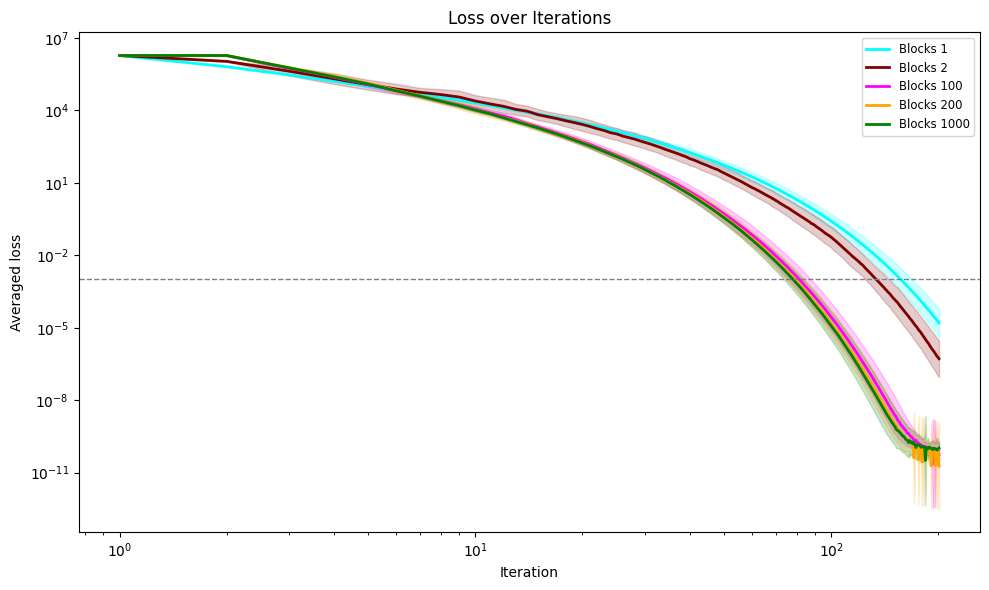

In [ ]:
import matplotlib
matplotlib.rcParams['text.usetex'] = False
start = 0
end = num_iterations+2
plot_loss_functions(start, end, F_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

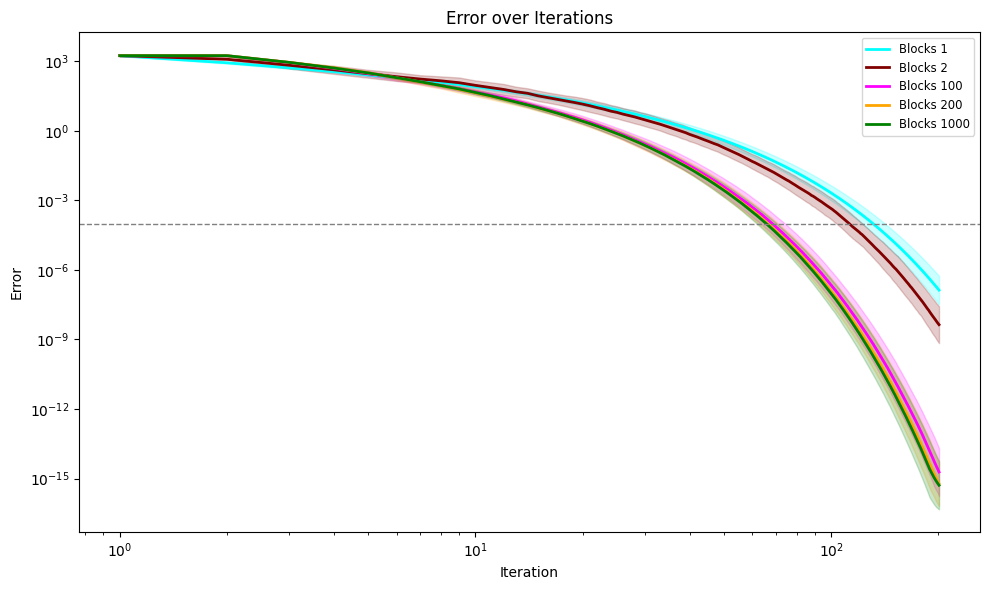

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
tol=1e-4
end = num_iterations+2
plot_error_iterations(start, end, E_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(F_CD[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-3)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    3.795e-05     4.045       163      3.297
       2    1.596e-06     2.922       140      2.045
     100    8.476e-11     2.865        85      1.218
     200    8.513e-11     2.943        81      1.192
    1000    1.166e-10     5.365        81      2.173


In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(E_CD[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-4)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    3.537e-07     4.045       135      2.731
       2    1.443e-08     2.922       117      1.709
     100    2.475e-14     2.865        71      1.017
     200    9.069e-15     2.943        68      1.001
    1000    3.920e-14     5.365        68      1.824


In [ ]:
def run_block_coordinate_descent_rand(
    p, d, cases, block_vector, length_vector,
    MC, num_iterations, Init, alpha1, acst,
    R_arr, fstar_arr, xstar_arr,
    noise=1.0, factor=1.9, data_seed=0
):
    """Random-subset block CD over the box, fresh (A,b) per MC. Uses the PRECOMPUTED constrained
       references R_arr/fstar_arr/xstar_arr (same as the other experiments)."""
    x_train_rand = np.zeros((p, cases, MC))
    F_CD_rand    = np.zeros((cases, num_iterations+1, MC))
    E_CD_rand    = np.zeros((cases, num_iterations+1, MC))
    CD_time_rand = np.zeros((cases, MC))

    for mc in range(MC):
        A_mc, b_mc = load_and_convert_dataset(d=d, p=p, noise=noise, seed=data_seed + mc)
        R     = R_arr[mc]
        fstar = fstar_arr[mc]
        xstar = xstar_arr[:, mc]
        lr_vec = step_sizes(A_mc, block_vector, length_vector, cases, alpha1, acst, factor=factor)
        x0 = Init[:, mc].copy()
        project_box(x0, -R, R, p)
        for k in range(cases):
            block, length, lr = block_vector[k], length_vector[k], lr_vec[k]
            random_blocks = np.argsort(
                np.random.random((num_iterations * block, p)), axis=1
            )[:, :length].astype(np.int64)
            r1 = np.zeros(d)
            for i in range(d):
                s = 0.0
                for j in range(p):
                    s += A_mc[i, j] * x0[j]
                r1[i] = s - b_mc[i]
            sq1 = 0.0
            for j in range(p):
                sq1 += x0[j]*x0[j]
            f0 = falpha(r1, sq1, alpha1, acst, d)
            t0 = time.time()
            x_f, F_hist, X = coordinate_descent_rand(
                A_mc, b_mc, p, d, block, length, num_iterations,
                x0, random_blocks, lr, alpha1, acst, r1, sq1, f0, R)
            t1 = time.time()
            diff = X - xstar[:, None]
            E_CD_rand[k, :, mc] = np.sum(diff*diff, axis=0)
            x_train_rand[:, k, mc] = x_f
            F_CD_rand[k, :, mc]    = F_hist - fstar
            CD_time_rand[k, mc]    = t1 - t0
        print(f"MC {mc}")
    return x_train_rand, F_CD_rand, CD_time_rand, E_CD_rand

In [ ]:
@njit
def coordinate_descent_rand(
    a, b, p, d, block, length, num_iterations,
    x0, random_blocks, lr, alpha1, acst, r1, sq1, f0, R):
    """Random-subset block CD over the box [-R,R]^p. Returns x, F_hist, X."""
    F_hist = np.zeros(num_iterations+1)
    X = np.zeros((p, num_iterations+1))
    x = x0.copy()
    r = r1.copy()
    sq = sq1
    F_hist[0] = f0
    X[:, 0] = x
    total_iters = num_iterations * block
    for it in range(total_iters):
        blk = random_blocks[it, :]
        gprime = gprime_h(r, sq, alpha1, acst, d)
        for jj in range(length):
            col = blk[jj]
            gh = 0.0
            for i in range(d):
                gh += a[i, col] * r[i]
            gh += alpha1 * x[col]
            g = gprime * gh
            x_new = x[col] - lr * g
            if x_new < -R:
                x_new = -R
            elif x_new > R:
                x_new = R
            dx = x_new - x[col]
            sq += 2.0*x[col]*dx + dx*dx
            x[col] = x_new
            for i in range(d):
                r[i] += a[i, col] * dx
        if it % block == 0:
            epoch = it // block
            F_hist[epoch+1] = falpha(r, sq, alpha1, acst, d)
            X[:, epoch+1] = x
    return x, F_hist, X

In [ ]:
x_train_rand, F_CD_rand, CD_time_rand, E_CD_rand = run_block_coordinate_descent_rand(
    p, d, cases, block_vector, length_vector,
    MC, num_iterations, Init, alpha1, acst,
    R_arr, fstar_arr, xstar_arr,
    noise=noise, factor=1.9, data_seed=data_seed)

MC 0
MC 1
MC 2
MC 3
MC 4
MC 5
MC 6
MC 7
MC 8
MC 9


In [ ]:
print(np.mean(CD_time_rand, axis=1))

[5.36145716 4.88698518 4.5345711  4.60061736 5.45971696]


In [ ]:
cases = len(block_vector)
print("train f:", F_CD_rand[:, num_iterations, MC-1])
print("train f:", E_CD_rand[:, num_iterations, MC-1])


train f: [8.05212767e-06 3.22517735e-07 7.63975549e-11 1.67347025e-10
 1.30967237e-10]
train f: [6.43771459e-08 2.55929770e-09 1.69846952e-16 5.07052070e-17
 6.78928949e-18]


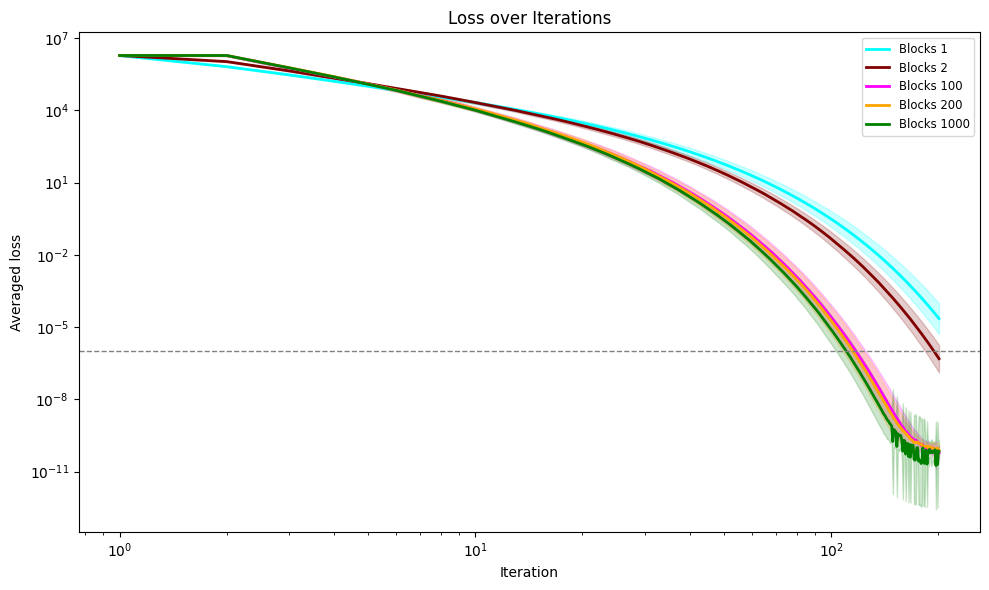

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
end = num_iterations+2
plot_loss_functions(start, end, F_CD_rand, block_vector, 1e-6, save_path="Coordinate_Descent0.1_20.jpeg")

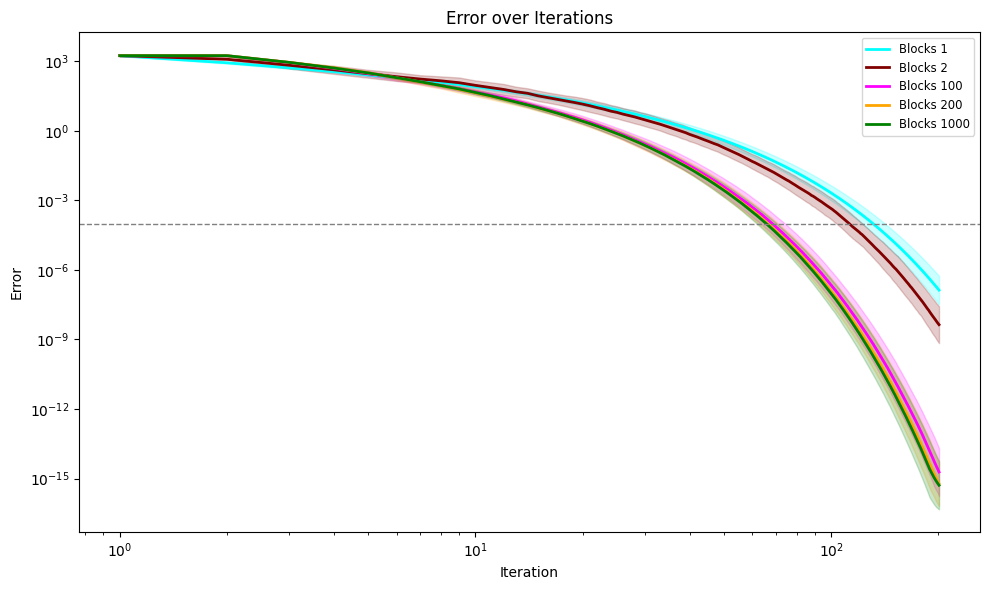

In [ ]:
matplotlib.rcParams['text.usetex'] = False
start = 0
tol=1e-4
end = num_iterations+2
plot_error_iterations(start, end, E_CD, block_vector, tol, save_path="Coordinate_Descent0.1_20.jpeg")

In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(F_CD_rand[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time_rand[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-3)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    6.028e-05     5.361       167      4.477
       2    1.226e-06     4.887       136      3.323
     100    7.112e-11     4.535        83      1.882
     200    9.059e-11     4.601        82      1.886
    1000    9.641e-11     5.460        79      2.157


In [ ]:
print(f"{'blocks':>8s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
for k, blk in enumerate(block_vector):
    mean_gap = np.mean(E_CD_rand[k, :, :], axis=1)     # averaged gap curve over MC
    tt       = np.mean(CD_time_rand[k, :])             # averaged runtime
    fg       = mean_gap[-1]
    n        = len(mean_gap) - 1                   # number of epochs
    below    = np.where(mean_gap <= 1e-4)[0]        # epochs at/under tolerance
    if len(below) > 0:
        ki = int(below[0])                         # first epoch reaching tol
        ti = tt * ki / n if n > 0 else 0.0         # interpolated wall-clock time
        hi_s, ht_s = f"{ki:.0f}", f"{ti:.3f}"
    else:
        hi_s, ht_s = "never", "never"
    print(f"{blk:8d} {fg:12.3e} {tt:9.3f} {hi_s:>9s} {ht_s:>10s}")

  blocks    final gap   time(s)  iter@tol   time@tol
       1    5.697e-07     5.361       139      3.726
       2    1.147e-08     4.887       113      2.761
     100    2.881e-14     4.535        69      1.564
     200    1.227e-14     4.601        69      1.587
    1000    3.295e-15     5.460        66      1.802


In [ ]:
def plot_loss_functions1(start, end, F_CD,tol):

    iterations =  range(start,end)
    print(len(iterations))
    colors=['aqua','orange','green','yellow','pink','black', 'maroon','fuchsia']
    Methods=['GD', 'NOUS_2 (our)','DOS_2 (our)','NOUS_100 (our)','DOS_100 (our)','Serial (our)', "SGD", "ZO"]
    count=0
    dim =F_CD.shape[0]
    for t in range(dim):
        # Compute mean and standard deviation for plotting shaded regions
        loss_f = F_CD[count, :, ]
        _eps = 1e-16
        _L = np.log10(np.maximum(loss_f, _eps))
        _m = np.mean(_L, axis = 1)
        _sd = np.std(_L, axis = 1)
        mean_value = 10**_m
        print(mean_value.shape)
        print(mean_value[0])
        # Plot of regret values over iterations
        # plt.figure(figsize=(10, 6))

        # Plot the mean regret line
        plt.plot(iterations, mean_value, label=Methods[count], color=colors[count], lw=2)
        plt.legend(loc='best',fontsize='small')
        # Plot shaded area (mean ± std_dev)
        # plt.fill_between(iterations, mean_regret - std_regret, mean_regret + std_regret,
        #              color=colors[count], alpha=0.2, label=f"Regret ± Std Dev with maximun delay {t}")
        plt.fill_between(iterations, 10**(_m - _sd), 10**(_m + _sd),
                     color=colors[count], alpha=0.2)
        count=count+1
    # Add labels and grid
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Averaged loss')
    plt.axhline(tol, ls='--', c='gray', lw=1)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('Coordinate_Descent0.1_20.jpeg')
    plt.show()

In [ ]:
F_CD_all = np.zeros((6, num_iterations+1,MC))
F_CD_all[0,:,:] = F_CD[0,:,:]
F_CD_all[1,:,:] = F_CD[1,:,:]
F_CD_all[3,:,:] = F_CD[2,:,:]
F_CD_all[5,:,:] = F_CD[4,:,:]
F_CD_all[2,:,:] = F_CD_rand[1,:,:]
F_CD_all[4,:,:] = F_CD_rand[2,:,:]
start = 1
end = num_iterations+2

201
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156


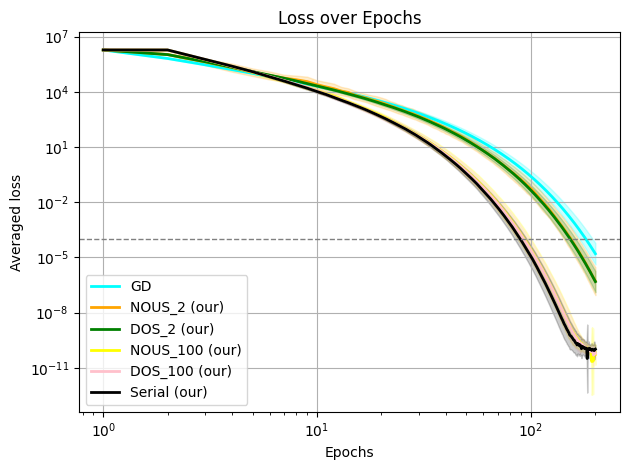

In [ ]:
plot_loss_functions1(start, end, F_CD_all,tol)

In [ ]:
# ===== Unified summary: CD, rand-CD, SGD, ZO with the SAME criteria =====
# final gap (mean over MC), runtime, and iter/time to reach tol (on the averaged gap curve).
tol =1e-3
def hit_inline(mean_gap, tt, tol):
    n = len(mean_gap) - 1
    below = np.where(mean_gap <= tol)[0]
    if len(below) == 0:
        return "never", "never"
    ki = int(below[0]); ti = tt*ki/n if n > 0 else 0.0
    return f"{ki:.0f}", f"{ti:.3f}"

print(f"{'method':>14s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
# block CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(F_CD[k, :, :], axis=1); tt = np.mean(CD_time[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'CD blocks '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# rand CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(F_CD_rand[k, :, :], axis=1); tt = np.mean(CD_time_rand[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'rand '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")

        method    final gap   time(s)  iter@tol   time@tol
   CD blocks 1    3.795e-05     4.045       163      3.297
   CD blocks 2    1.596e-06     2.922       140      2.045
 CD blocks 100    8.476e-11     2.865        85      1.218
 CD blocks 200    8.513e-11     2.943        81      1.192
CD blocks 1000    1.166e-10     5.365        81      2.173
        rand 1    6.028e-05     5.361       167      4.477
        rand 2    1.226e-06     4.887       136      3.323
      rand 100    7.112e-11     4.535        83      1.882
      rand 200    9.059e-11     4.601        82      1.886
     rand 1000    9.641e-11     5.460        79      2.157


In [ ]:
F_CD_all = np.zeros((6, num_iterations+1,MC))
F_CD_all[0,:] = F_CD[0,:,:]
F_CD_all[1,:] = F_CD[1,:,:]
F_CD_all[3,:] = F_CD[2,:,:]
F_CD_all[5,:] = F_CD[4,:,:]
F_CD_all[2,:] = F_CD_rand[1,:,:]
F_CD_all[4,:] = F_CD_rand[2,:,:]

201
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156
(201,)
1894115.1596174156


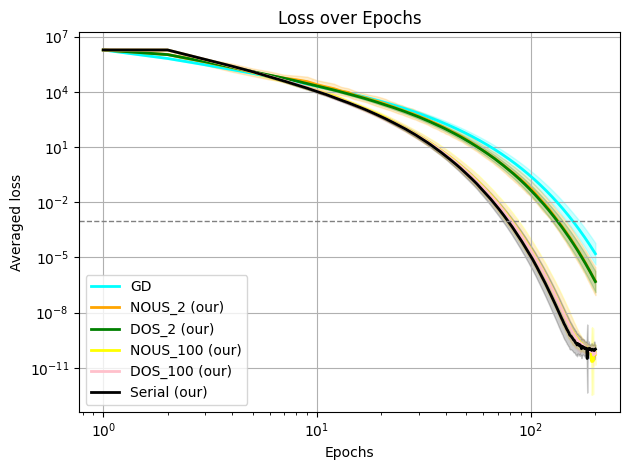

In [ ]:
tol =1e-3
plot_loss_functions1(start, end, F_CD_all,tol)

In [ ]:
def plot_loss_functions2(start, end, F_CD,tol):

    iterations =  range(start,end)
    print(len(iterations))
    colors=['aqua','orange','green','yellow','pink','black', 'maroon','fuchsia']
    Methods=['GD', 'NOUS_2 (our)','DOS_2 (our)','NOUS_100 (our)','DOS_100 (our)','Serial (our)', "SGD", "ZO"]
    count=0
    dim =F_CD.shape[0]
    for t in range(dim):
        # Compute mean and standard deviation for plotting shaded regions
        loss_f = F_CD[count, :, ]
        _eps = 1e-16
        _L = np.log10(np.maximum(loss_f, _eps))
        _m = np.mean(_L, axis = 1)
        _sd = np.std(_L, axis = 1)
        mean_value = 10**_m
        print(mean_value.shape)
        print(mean_value[0])
        # Plot of regret values over iterations
        # plt.figure(figsize=(10, 6))

        # Plot the mean regret line
        plt.plot(iterations, mean_value, label=Methods[count], color=colors[count], lw=2)
        plt.legend(loc='best',fontsize='small')
        # Plot shaded area (mean ± std_dev)
        # plt.fill_between(iterations, mean_regret - std_regret, mean_regret + std_regret,
        #              color=colors[count], alpha=0.2, label=f"Regret ± Std Dev with maximun delay {t}")
        plt.fill_between(iterations, 10**(_m - _sd), 10**(_m + _sd),
                     color=colors[count], alpha=0.2)
        count=count+1
    # Add labels and grid
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Iteration error over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Averaged iteration error')
    plt.axhline(tol, ls='--', c='gray', lw=1)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig('Coordinate_Descent0.1_20.jpeg')
    plt.show()

In [ ]:
E_CD_all = np.zeros((6, num_iterations+1,MC))
E_CD_all[0,:] = E_CD[0,:,:]
E_CD_all[1,:] = E_CD[1,:,:]
E_CD_all[3,:] = E_CD[2,:,:]
E_CD_all[5,:] = E_CD[4,:,:]
E_CD_all[2,:] = E_CD_rand[1,:,:]
E_CD_all[4,:] = E_CD_rand[2,:,:]
tol =1e-3

In [ ]:
# ===== Unified summary: CD, rand-CD, SGD, ZO with the SAME criteria =====
# final gap (mean over MC), runtime, and iter/time to reach tol (on the averaged gap curve).
def hit_inline(mean_gap, tt, tol):
    n = len(mean_gap) - 1
    below = np.where(mean_gap <= tol)[0]
    if len(below) == 0:
        return "never", "never"
    ki = int(below[0]); ti = tt*ki/n if n > 0 else 0.0
    return f"{ki:.0f}", f"{ti:.3f}"

print(f"{'method':>14s} {'final gap':>12s} {'time(s)':>9s} {'iter@tol':>9s} {'time@tol':>10s}")
# block CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(E_CD[k, :, :], axis=1); tt = np.mean(CD_time[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'CD blocks '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")
# rand CD cases
for k, blk in enumerate(block_vector):
    mg = np.mean(E_CD_rand[k, :, :], axis=1); tt = np.mean(CD_time_rand[k, :])
    hi, ht = hit_inline(mg, tt, tol)
    print(f"{'rand '+str(blk):>14s} {mg[-1]:12.3e} {tt:9.3f} {hi:>9s} {ht:>10s}")

        method    final gap   time(s)  iter@tol   time@tol
   CD blocks 1    3.537e-07     4.045       110      2.225
   CD blocks 2    1.443e-08     2.922        96      1.403
 CD blocks 100    2.475e-14     2.865        58      0.831
 CD blocks 200    9.069e-15     2.943        56      0.824
CD blocks 1000    3.920e-14     5.365        56      1.502
        rand 1    5.697e-07     5.361       113      3.029
        rand 2    1.147e-08     4.887        93      2.272
      rand 100    2.881e-14     4.535        57      1.292
      rand 200    1.227e-14     4.601        57      1.311
     rand 1000    3.295e-15     5.460        54      1.474


201
(201,)
1730.6728610887988
(201,)
1730.6728610887988
(201,)
1730.6728610887988
(201,)
1730.6728610887988
(201,)
1730.6728610887988
(201,)
1730.6728610887988


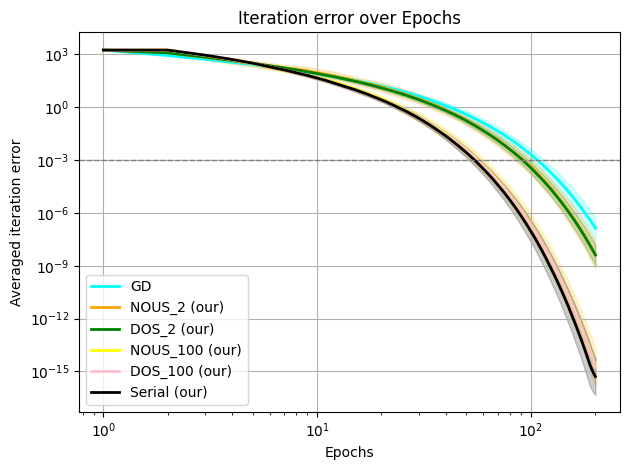

In [ ]:
tol =1e-3
plot_loss_functions2(start, end, E_CD_all,tol)